#### nota desta aula

recentemente, o sklearn 0.17 e 0.19 fizeram algumas mudanças na sua biblioteca.
penalty era um parametro usado para adicionar l1 e l2 e foi substituido pelo l1_ratio

por conta disso, os solvers tb sofreram mudanças. nem todos aceitam l1(l1_ratio=1) ou l2 (l1_ratio=0)
liblinear agora não aceita multiclasses apenas bivaloração

seguir como abaixo:

| solver | l1_ratio | multiclass |
| --- | --- | --- | 
| ‘lbfgs’ | l1_ratio=0 | yes |
| ‘liblinear’ | l1_ratio=1 or l1_ratio=0 | no |
| ‘newton-cg’ | l1_ratio=0 | yes |
| ‘newton-cholesky’ | l1_ratio=0 | yes |
| ‘sag’ | l1_ratio=0 | yes |
| ‘saga’ | 0<=l1_ratio<=1 | yes |




#### Criando um dataset

In [3]:
import numpy as np

def generate_dataset(size, classes=2, noise=0.5):

    # Generate random datapoints
    labels = np.random.randint(0, classes, size)
    labels_err = np.random.random(size) * 0.25

    x = (np.random.rand(size)-labels_err  + labels) / classes
    y = x + np.random.rand(size) * noise


    # Reshape data in order to merge them
    #x = x.reshape(size, 1)
    #y = y.reshape(size, 1)
    #labels = labels.reshape(size, 1)
    # Merge the data
    #data = np.hstack((x, y, labels))

    return x, y, labels

In [4]:
X, Y, Label = generate_dataset(250, classes=2, noise=0.5)
data = np.hstack((X.reshape(len(X),1), Y.reshape(len(Y),1)))

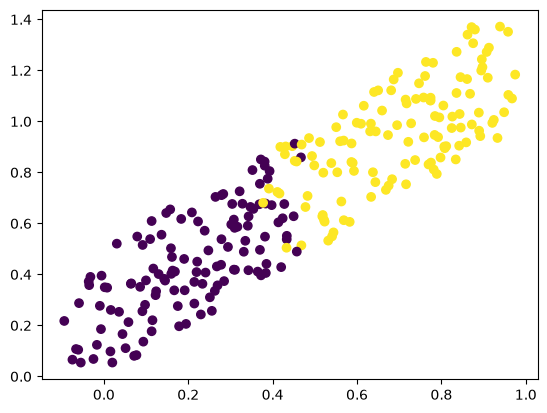

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X, Y, c=Label)
plt.show()

## Regressão Logistica

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(data,Label, test_size=0.25)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
lr = LogisticRegression()
lr.fit(X_train, Y_train)

print(lr.score(X_test, Y_test))

0.9365079365079365


In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, data,Label, scoring='accuracy', cv=10)
scores

array([1.  , 0.92, 0.92, 0.92, 1.  , 1.  , 0.8 , 0.92, 0.96, 0.92])

In [9]:
print(scores.mean())
print(scores.std())

0.9360000000000002
0.05713142742834279


In [10]:
print(lr.intercept_)
print(lr.coef_)

[-4.33991157]
[[4.39652943 3.3539825 ]]


#### usando o sklearn para criar um dataset

In [11]:
from sklearn.datasets import make_classification

nb_samples = 500
X, Y = make_classification(n_samples=nb_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)


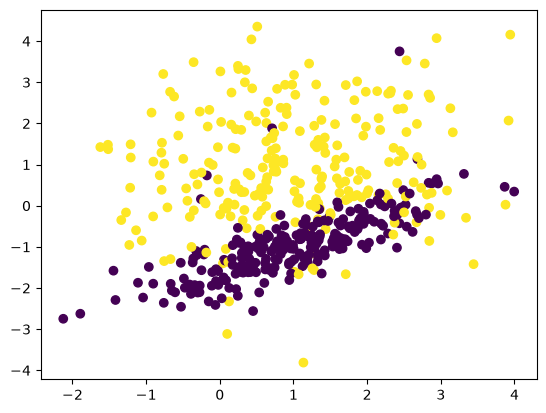

In [12]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.25)

model = LogisticRegression()
# fit the model
model.fit(X, Y)
print(model.score(X, Y))

0.888


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, Y, scoring='accuracy', cv=10)
scores

array([0.84, 0.98, 0.9 , 0.92, 0.88, 0.82, 0.88, 0.9 , 0.9 , 0.84])

In [15]:
print(scores.mean())
print(scores.std())

0.8859999999999999
0.043863424398922636


In [16]:
print(lr.intercept_)
print(lr.coef_)

[-4.33991157]
[[4.39652943 3.3539825 ]]


#### desenhando a separação

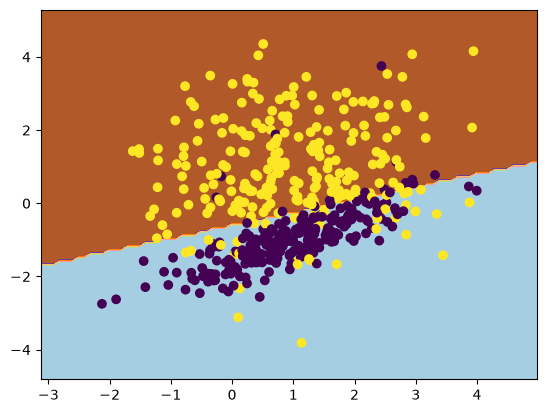

In [17]:
from numpy import meshgrid
from numpy import arange
from numpy import hstack
from numpy import where

# define bounds of the domain
min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1


# define the x and y scale
x1grid = arange(min1, max1, 0.1)
x2grid = arange(min2, max2, 0.1)


# create all of the lines and rows of the grid
xx, yy = meshgrid(x1grid, x2grid)


# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))


# horizontal stack vectors to create x1,x2 input for the model
grid = hstack((r1,r2))

# make predictions for the grid
yhat = model.predict(grid)
y_prob = model.predict_proba(X_test)[:, 1]

# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)


# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')

plt.scatter(X[:, 0], X[:, 1], c=Y)

# show the plot
plt.show()

In [18]:
model.predict_proba(X_test)[:, 1]

array([0.27827926, 0.64086649, 0.9977341 , 0.43839773, 0.79101499,
       0.12128624, 0.97901371, 0.42834053, 0.39795069, 0.24712976,
       0.5601914 , 0.0691916 , 0.77475273, 0.05707051, 0.99423461,
       0.07432176, 0.93035876, 0.36690273, 0.91689506, 0.0767501 ,
       0.16064474, 0.99897943, 0.20851438, 0.19293855, 0.87063917,
       0.0938544 , 0.99764677, 0.19901906, 0.97632612, 0.92897681,
       0.16616204, 0.82928781, 0.09568835, 0.89693966, 0.05734822,
       0.97137928, 0.99103766, 0.98160547, 0.97835661, 0.02570374,
       0.54763655, 0.99748686, 0.1083377 , 0.98432216, 0.34905103,
       0.18231704, 0.897756  , 0.168237  , 0.03206545, 0.84341423,
       0.19605025, 0.09419742, 0.52948994, 0.26708145, 0.07704852,
       0.9470703 , 0.61941203, 0.95563886, 0.98017684, 0.99813455,
       0.81171023, 0.67721642, 0.56482113, 0.69440337, 0.07348845,
       0.23428991, 0.28980359, 0.28705621, 0.17939484, 0.03170873,
       0.11250613, 0.9939791 , 0.25221014, 0.49158112, 0.88559

### Gradiente Descentente Estocástico

In [19]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='perceptron', learning_rate='optimal')

cross_val_score(sgd, X, Y, scoring='accuracy', cv=10).mean()

np.float64(0.8220000000000001)

In [20]:
from sklearn.linear_model import Perceptron

perc = Perceptron()

cross_val_score(perc, X, Y, scoring='accuracy', cv=10).mean()

np.float64(0.798)

## Passive-aggressive algorithms

In [21]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

iris = load_iris()

ss = StandardScaler()

X = ss.fit_transform(iris['data'])
Y = iris['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1000)

nb_initial_samples = int(X_train.shape[0] / 1.5)

In [27]:
#PassiveAggressiveClassifier será descontinuado na versÃo 1.10
#from sklearn.linear_model import PassiveAggressiveClassifier
#pac = PassiveAggressiveClassifier(C=0.05, loss='squared_hinge', max_iter=2000, random_state=1000)
#pac.fit(X_train[0:nb_initial_samples], Y_train[0:nb_initial_samples])


from sklearn.linear_model import SGDClassifier

pac = SGDClassifier(
    loss='hinge',
    penalty=None,
    learning_rate='pa1',
    eta0=1.0,
    max_iter=2000,
    random_state=1000
)

pac.fit(
    X_train[:nb_initial_samples],
    Y_train[:nb_initial_samples]
)

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",1000
,"learning_rate learning_rate: str, default='optimal'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where `t0` is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': `eta = eta0`, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if `early_stopping` is `True`, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='hinge'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='hinge'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'pa1'
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01, but note that eta0 is not usedby the default learning rate 'optimal'.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",1.0
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfu

In [28]:
import numpy as np

validation_accuracies = []
print(nb_initial_samples)
print(X_train.shape[0])
for (x, y) in zip(X_train[nb_initial_samples:], Y_train[nb_initial_samples:]):
    pac.partial_fit(x.reshape(1, -1), y.ravel(), classes=np.unique(iris['target']))
    validation_accuracies.append(pac.score(X_test, Y_test))

70
105


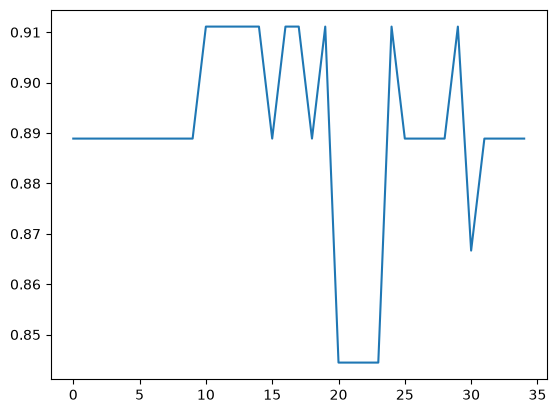

In [29]:
plt.plot(validation_accuracies)
plt.show()

## Encontrar hiperparametros ótimos usando o Grid Search

In [40]:
import multiprocessing

from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV

iris = load_iris()

param_grid = [
   {
      'l1_ratio': [0.0, 1.0], #'penalty': [ 'l1', 'l2' ],
      'C': [ 0.5, 1.0, 1.5, 1.8, 2.0, 2.5],
       'solver':['saga'], # 'lbfgs','liblinear'],
       'max_iter':[2000]
   }
]

gs = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid,
   scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())




In [41]:
gs.fit(iris.data, iris.target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.5, 1.0, ...], 'l1_ratio': [0.0, 1.0], 'max_iter': [2000], 'solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the v

In [42]:
print(gs.best_estimator_)
print(cross_val_score(gs.best_estimator_, iris.data, iris.target, scoring='accuracy', cv=10).mean())

LogisticRegression(C=1.5, max_iter=2000, solver='saga')
0.9866666666666667


#### vamos tentar com um perceptron?

In [45]:
import multiprocessing

from sklearn.model_selection import GridSearchCV

param_grid = [
   {
       'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0], #'penalty': [ 'l1', 'l2', 'elasticnet' ],
       'alpha': [ 1e-5, 1e-4, 5e-4, 1e-3, 2.3e-3, 5e-3, 1e-2],
       'l1_ratio': [0.01, 0.05, 0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 0.8]
   }
]

sgd = SGDClassifier(loss='perceptron', learning_rate='optimal')
gs = GridSearchCV(estimator=sgd, param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

gs.fit(iris.data, iris.target)

print(gs.best_estimator_)
print(gs.best_score_)

SGDClassifier(alpha=0.01, l1_ratio=0.35, loss='perceptron')
0.9199999999999999


## Métricas de Classificação

In [46]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

nb_samples = 500

X, Y = make_classification(n_samples=nb_samples, n_features=2, n_informative=2, n_redundant=0,
 n_clusters_per_class=1, random_state=1000)


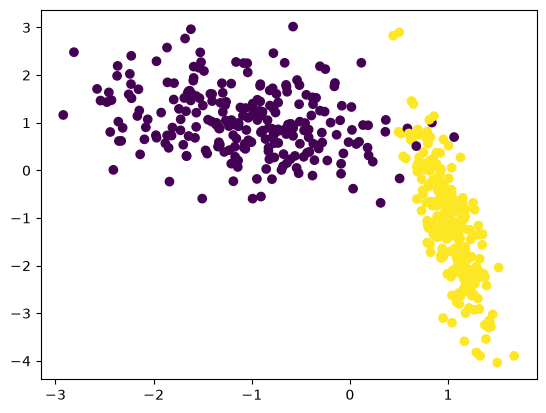

In [47]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1000)


lr = LogisticRegression()
lr.fit(X_train, Y_train)

from sklearn.metrics import accuracy_score

print(accuracy_score(Y_test, lr.predict(X_test)))


0.96


#### desenhando a separação

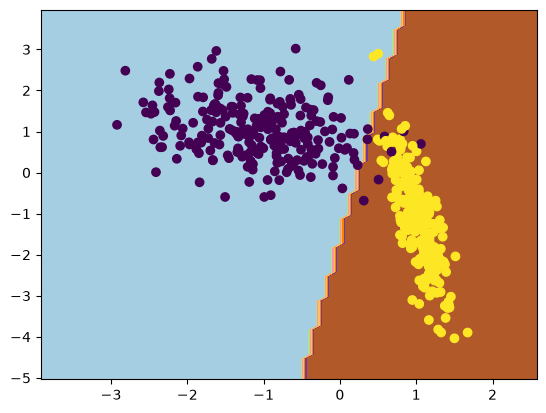

In [49]:
from numpy import meshgrid
from numpy import arange
from numpy import hstack
from numpy import where

# define bounds of the domain
min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1


# define the x and y scale
x1grid = arange(min1, max1, 0.1)
x2grid = arange(min2, max2, 0.1)


# create all of the lines and rows of the grid
xx, yy = meshgrid(x1grid, x2grid)


# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))


# horizontal stack vectors to create x1,x2 input for the model
grid = hstack((r1,r2))

# make predictions for the grid
yhat = lr.predict(grid)

# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)


# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')

plt.scatter(X[:, 0], X[:, 1], c=Y)

# show the plot
plt.show()

#### Perda Zero-um

In [50]:
from sklearn.metrics import zero_one_loss

print(zero_one_loss(Y_test, lr.predict(X_test)))

print(zero_one_loss(Y_test, lr.predict(X_test), normalize=False))


0.040000000000000036
6.0


#### Coeficiente de similaridade de Jaccard

In [51]:
from sklearn.metrics import jaccard_score

print(jaccard_score(Y_test, lr.predict(X_test)))


0.9230769230769231


### Matriz de Confusão

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=1000)

lr = LogisticRegression()
lr.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=Y_test, y_pred=lr.predict(X_test))

print(cm[::-1, ::-1])

[[61  1]
 [ 3 60]]


In [54]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

def plot_confusion_matrix(Y_test, Y_pred, targets):
    labels = range(len(targets))

    cmatrix = confusion_matrix(
        y_true=Y_test,
        y_pred=Y_pred,
        labels=labels
    )

    cm_fig, cm_ax = plt.subplots(figsize=(8, 8))
    cm_ax.matshow(cmatrix, cmap=cm.GnBu)

    cm_ax.set_xticks(range(len(targets)))
    cm_ax.set_yticks(range(len(targets)))

    cm_ax.set_xticklabels(targets)
    cm_ax.set_yticklabels(targets)

    cm_ax.set_xlabel('Predito')
    cm_ax.set_ylabel('Real')

    for i in range(len(targets)):
        for j in range(len(targets)):
            cm_ax.text(
                j, i,
                cmatrix[i, j],
                va='center',
                ha='center',
                size='x-large'
            )

    plt.title('Matriz de Confusão')
    plt.show()

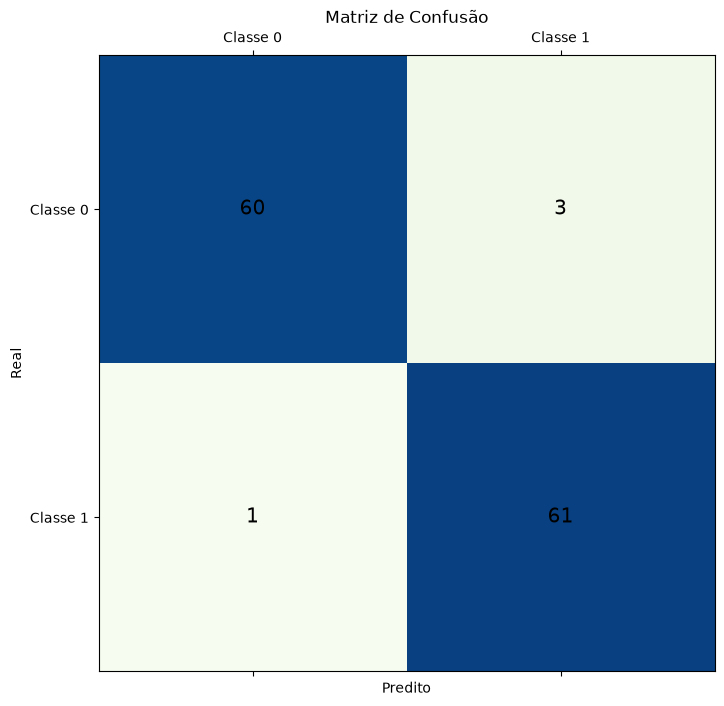

In [55]:
plot_confusion_matrix(Y_test, lr.predict(X_test), list(['Classe 0','Classe 1']))

## Database Wine

D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


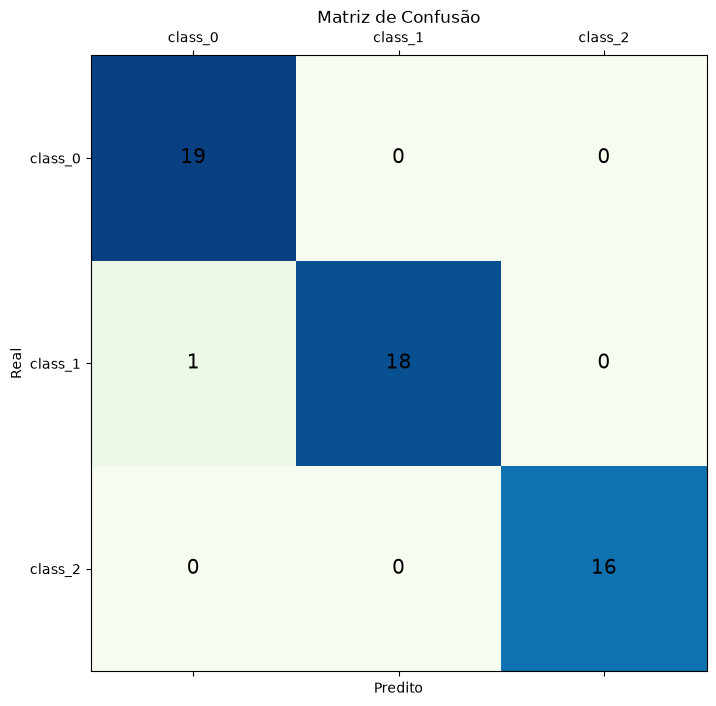

0.9814814814814815


In [58]:
from sklearn.metrics import confusion_matrix

from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score

wine = load_wine()

X_train_wine, X_test_wine, Y_train_wine, Y_test_wine = train_test_split(wine["data"], wine["target"], test_size=0.3)

lr_wine = LogisticRegression(solver='lbfgs') # 'liblinear'
lr_wine.fit(X_train_wine, Y_train_wine)

plot_confusion_matrix(lr_wine.predict(X_test_wine), Y_test_wine, list(wine['target_names']))
print(accuracy_score(Y_test_wine, lr_wine.predict(X_test_wine)))

In [59]:
import numpy as np
import copy as cp
from typing import Tuple
from sklearn.model_selection import StratifiedKFold, cross_val_score

def cross_val_predict(model, kfold : StratifiedKFold, X : np.array, y : np.array) -> Tuple[np.array, np.array, np.array]:

    model_ = cp.deepcopy(model)

    no_classes = len(np.unique(y))

    actual_classes = np.empty([0], dtype=int)
    predicted_classes = np.empty([0], dtype=int)
    predicted_proba = np.empty([0, no_classes])

    for train_ndx, test_ndx in kfold.split(X,y):

        train_X, train_y, test_X, test_y = X[train_ndx], y[train_ndx], X[test_ndx], y[test_ndx]

        actual_classes = np.append(actual_classes, test_y)

        model_.fit(train_X, train_y)
        predicted_classes = np.append(predicted_classes, model_.predict(test_X))

        try:
            predicted_proba = np.append(predicted_proba, model_.predict_proba(test_X), axis=0)
        except:
            predicted_proba = np.append(predicted_proba, np.zeros((len(test_X), no_classes), dtype=float), axis=0)

    return actual_classes, predicted_classes, predicted_proba

D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-

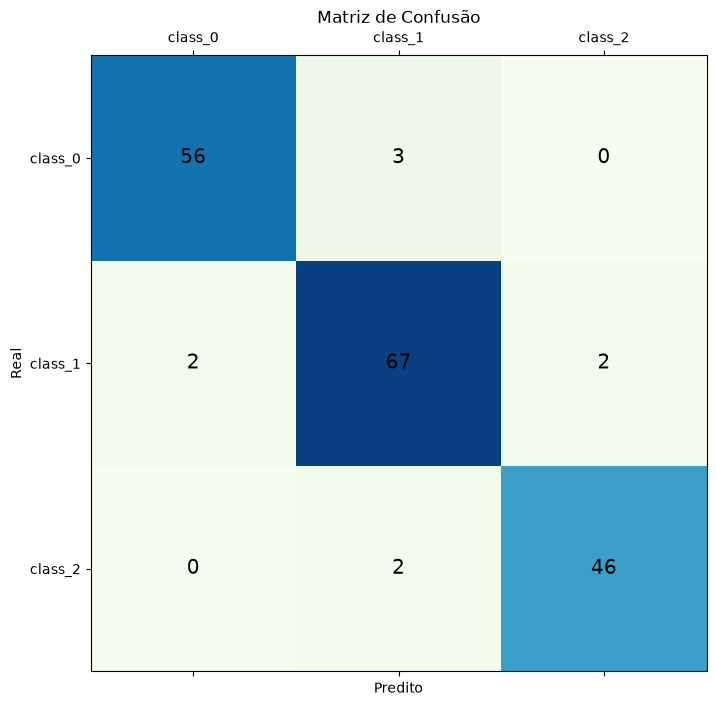

0.95


In [60]:
# Validação cruzada estratificada K Fold (ou K-Fold estratificado)
kfold = StratifiedKFold(n_splits=10,  shuffle=False)

cv_results = cross_val_score(lr_wine, wine["data"], wine["target"], scoring='accuracy', cv=kfold)

actual_classes, predicted_classes, _ = cross_val_predict(lr_wine, kfold, wine["data"], wine["target"])

plot_confusion_matrix(actual_classes, predicted_classes, list(wine['target_names']))
print(cv_results.mean())

In [61]:
from sklearn.metrics import classification_report
print(classification_report(actual_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        59
           1       0.93      0.94      0.94        71
           2       0.96      0.96      0.96        48

    accuracy                           0.95       178
   macro avg       0.95      0.95      0.95       178
weighted avg       0.95      0.95      0.95       178



### Previsão e Recall

In [62]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

#Exemplo Conjunto de pontos
print("Precision Score : ",precision_score(Y_test,lr.predict(X_test),average='micro'))
print("Recall Score :" , recall_score(Y_test, lr.predict(X_test), average='micro') )

Precision Score :  0.968
Recall Score : 0.968


In [63]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

#Exemplo Dataset wine
print("CV Precision Score : ",precision_score(actual_classes, predicted_classes, average='micro'))
print("CV Recall Score :" , recall_score(actual_classes, predicted_classes, average='micro') )


CV Precision Score :  0.949438202247191
CV Recall Score : 0.949438202247191


### Score FBeta

In [64]:
from sklearn.metrics import fbeta_score

#Exemplo Conjunto de pontos
print(fbeta_score(Y_test, lr.predict(X_test), beta=1, average='micro'))
print(fbeta_score(Y_test, lr.predict(X_test), beta=0.75, average='micro'))
print(fbeta_score(Y_test, lr.predict(X_test), beta=1.25, average='micro'))
print(fbeta_score(actual_classes, predicted_classes, beta=1.25, average='micro'))

0.968
0.968
0.968
0.949438202247191


In [65]:
from sklearn.metrics import fbeta_score

#Exemplo Dataset wine
print(fbeta_score(actual_classes, predicted_classes, beta=1, average='micro'))
print(fbeta_score(actual_classes, predicted_classes, beta=0.75, average='micro'))
print(fbeta_score(actual_classes, predicted_classes, beta=1.25, average='micro'))

0.949438202247191
0.949438202247191
0.949438202247191


### Score Cohen Kappa

In [66]:
from sklearn.metrics import cohen_kappa_score

#Exemplo Conjunto de pontos
print(cohen_kappa_score(Y_test, lr.predict(X_test)))

0.9360122856411569


In [67]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97        63
           1       0.95      0.98      0.97        62

    accuracy                           0.97       125
   macro avg       0.97      0.97      0.97       125
weighted avg       0.97      0.97      0.97       125



In [68]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X, Y, test_size=0.25, random_state=1000)

lr2 = LogisticRegression()
lr2.fit(X_train2, Y_train2)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=Y_test2, y_pred=lr2.predict(X_test2))

print(cm[::-1, ::-1])

[[61  1]
 [ 3 60]]


In [69]:
from sklearn.metrics import cohen_kappa_score

#Exemplo Dataset wine
print(cohen_kappa_score(actual_classes,predicted_classes))

0.9231507243595893


In [70]:
from sklearn.metrics import classification_report
print(classification_report(actual_classes,predicted_classes))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        59
           1       0.93      0.94      0.94        71
           2       0.96      0.96      0.96        48

    accuracy                           0.95       178
   macro avg       0.95      0.95      0.95       178
weighted avg       0.95      0.95      0.95       178



In [71]:
X_train_wine2, X_test_wine2, Y_train_wine2, Y_test_wine2 = train_test_split(wine["data"], wine["target"], test_size=0.25, random_state=1000)

lr_wine2 = LogisticRegression()
lr_wine2.fit(X_train_wine2, Y_train_wine2)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=Y_test_wine2, y_pred=lr_wine2.predict(X_test_wine2))

print(cm[::-1, ::-1])

[[12  1  0]
 [ 1 17  3]
 [ 0  0 11]]


D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### novo exemplo pontos Cohen Kappa

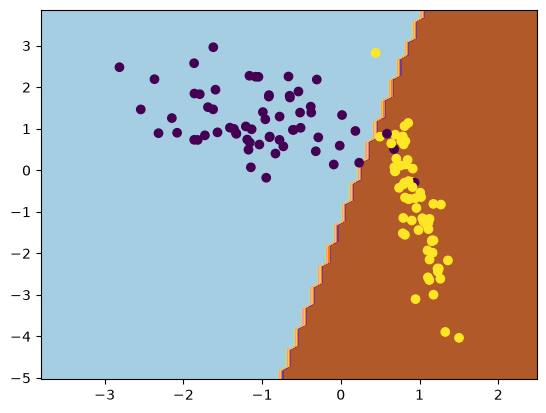

In [72]:
from numpy import meshgrid
from numpy import arange
from numpy import hstack
from numpy import where

def show_bounds(lr, X_test):
    # define bounds of the domain
    min1, max1 = X_test[:, 0].min()-1, X_test[:, 0].max()+1
    min2, max2 = X_test[:, 1].min()-1, X_test[:, 1].max()+1
    
    
    # define the x and y scale
    x1grid = arange(min1, max1, 0.1)
    x2grid = arange(min2, max2, 0.1)
    
    
    # create all of the lines and rows of the grid
    xx, yy = meshgrid(x1grid, x2grid)
    
    
    # flatten each grid to a vector
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
    
    
    # horizontal stack vectors to create x1,x2 input for the model
    grid = hstack((r1,r2))
    
    # make predictions for the grid
    yhat = lr.predict(grid)
    
    # reshape the predictions back into a grid
    zz = yhat.reshape(xx.shape)
    
    
    # plot the grid of x, y and z values as a surface
    plt.contourf(xx, yy, zz, cmap='Paired')
    
    plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test)
    
    # show the plot
    plt.show()

show_bounds(lr, X_test)

In [73]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97        63
           1       0.95      0.98      0.97        62

    accuracy                           0.97       125
   macro avg       0.97      0.97      0.97       125
weighted avg       0.97      0.97      0.97       125



In [74]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

print("Precision Score : ",precision_score(Y_test,lr.predict(X_test),average='micro'))
print("Recall Score :" , recall_score(Y_test, lr.predict(X_test), average='micro') )

Precision Score :  0.968
Recall Score : 0.968


In [75]:
from sklearn.metrics import fbeta_score

print(fbeta_score(Y_test, lr.predict(X_test), beta=1, average='micro'))
print(fbeta_score(Y_test, lr.predict(X_test), beta=0.75, average='micro'))
print(fbeta_score(Y_test, lr.predict(X_test), beta=1.25, average='micro'))

0.968
0.968
0.968


In [76]:
from sklearn.metrics import cohen_kappa_score

print(cohen_kappa_score(Y_test, lr.predict(X_test)))

0.9360122856411569


### Sumário de Classificação

In [77]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97        63
           1       0.95      0.98      0.97        62

    accuracy                           0.97       125
   macro avg       0.97      0.97      0.97       125
weighted avg       0.97      0.97      0.97       125



## Curva de Aprendizado

In [79]:
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle

wine = load_wine()

X, Y = shuffle(wine['data'], wine['target'])

tsize, training_score, test_score = learning_curve(LogisticRegression(solver='lbfgs'), X, Y, cv=20, random_state=1000)

avg_tr_scores = np.mean(training_score, axis=1)
avg_test_scores = np.mean(test_score, axis=1)

D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-

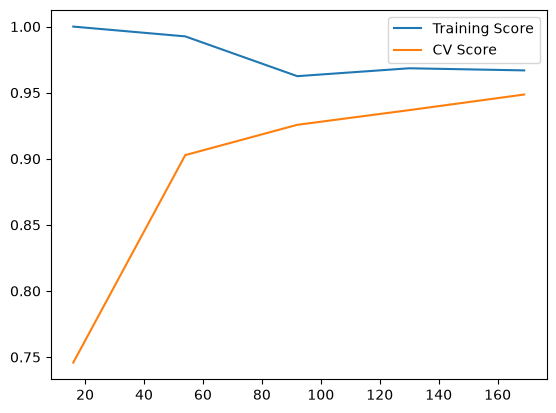

In [81]:
plt.plot(tsize,avg_tr_scores,label='Training Score')
plt.plot(tsize,avg_test_scores,label='CV Score')
plt.legend()
plt.show()

In [83]:
wine = load_wine()

X, Y = (wine['data'], wine['target'])

# K-Fold estratificado
# embaralha antes de construir os folds
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

# embaralha antes de criar os subconjuntos
tsize, training_score, test_score = learning_curve(LogisticRegression(solver='lbfgs',  max_iter=1000), X, Y, cv=kfold, shuffle=True, random_state=1000)

avg_tr_scores = np.mean(training_score, axis=1)
avg_test_scores = np.mean(test_score, axis=1)

D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

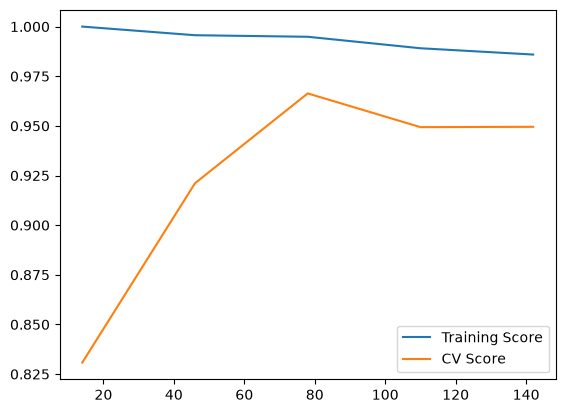

In [84]:
plt.plot(tsize,avg_tr_scores,label='Training Score')
plt.plot(tsize,avg_test_scores,label='CV Score')
plt.legend()
plt.show()

##  Curva Característica de Operação do Receptor  (Curva ROC)

In [85]:
from sklearn.datasets import make_classification

nb_samples = 500
X, Y = make_classification(n_samples=nb_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

lr = LogisticRegression(solver='liblinear')
lr.fit(X_train, Y_train)

Y_scores = lr.decision_function(X_test)


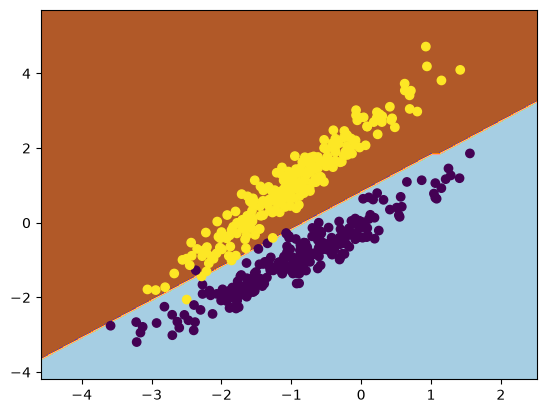

In [86]:
from numpy import meshgrid
from numpy import arange
from numpy import hstack
from numpy import where

# define bounds of the domain
min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1


# define the x and y scale
x1grid = arange(min1, max1, 0.1)
x2grid = arange(min2, max2, 0.1)


# create all of the lines and rows of the grid
xx, yy = meshgrid(x1grid, x2grid)


# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))


# horizontal stack vectors to create x1,x2 input for the model
grid = hstack((r1,r2))

# make predictions for the grid
yhat = lr.predict(grid)

# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)


# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')

plt.scatter(X[:, 0], X[:, 1], c=Y)

# show the plot
plt.show()

In [87]:
print(lr.score(X_test, Y_test))

1.0


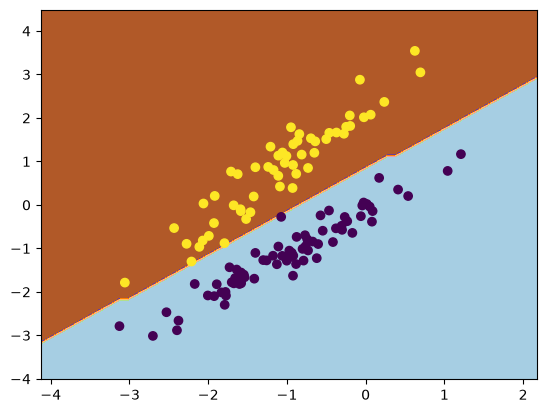

In [88]:
from numpy import meshgrid
from numpy import arange
from numpy import hstack
from numpy import where

# define bounds of the domain
min1, max1 = X_test[:, 0].min()-1, X_test[:, 0].max()+1
min2, max2 = X_test[:, 1].min()-1, X_test[:, 1].max()+1


# define the x and y scale
x1grid = arange(min1, max1, 0.1)
x2grid = arange(min2, max2, 0.1)


# create all of the lines and rows of the grid
xx, yy = meshgrid(x1grid, x2grid)


# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))


# horizontal stack vectors to create x1,x2 input for the model
grid = hstack((r1,r2))

# make predictions for the grid
yhat = lr.predict(grid)

# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)


# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')

plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test)

# show the plot
plt.show()

In [89]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_scores)

In [90]:
from sklearn.metrics import auc

print(auc(fpr, tpr))

1.0


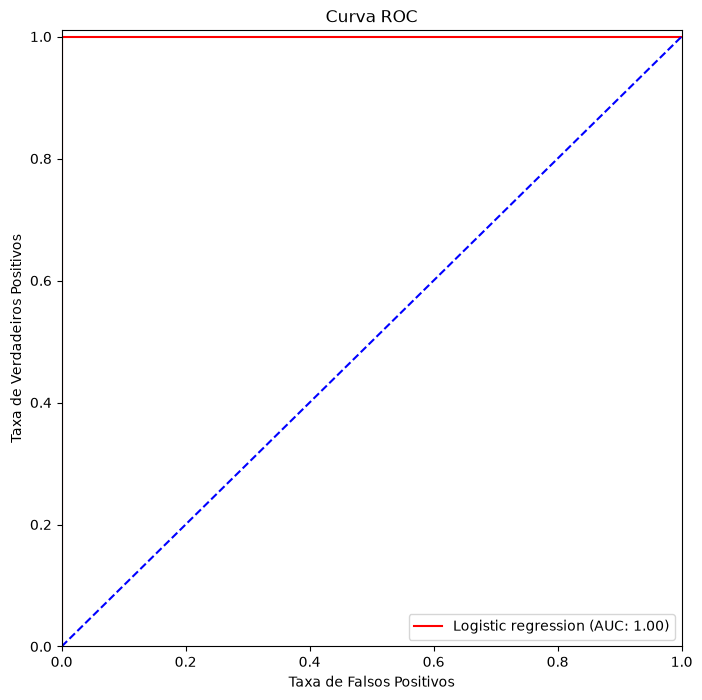

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='red', label='Logistic regression (AUC: %.2f)' % auc(fpr, tpr))
plt.plot([0, 1], [0, 1], color='blue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend(loc="lower right")

plt.show()

D:\Backup\OneDrive - puc-rio.br\Jupyter\venvs\mlclass\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


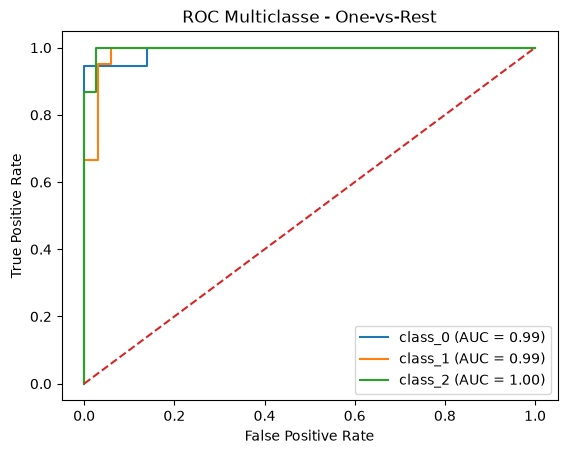

In [93]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

wine = load_wine()

X, Y = wine.data, wine.target

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    stratify=Y,
    random_state=1000
)

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, Y_train)

# Probabilidade de cada classe
Y_prob = model.predict_proba(X_test)

# Y_test: [0, 2, 1, 0, ...]
# Y_bin:  [[1,0,0], [0,0,1], [0,1,0], ...]
Y_bin = label_binarize(Y_test, classes=[0, 1, 2])

for i in range(3):
    fpr, tpr, thresholds = roc_curve(
        Y_bin[:, i],
        Y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{wine.target_names[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Multiclasse - One-vs-Rest')
plt.legend()

plt.show()